# Store Analysis

Source: stores_clean.parquet, sales_clean.parquet

Covers: store count by country, size distribution, store age, online vs physical, revenue per store

### Imports

In [1]:
import pandas as pd
from src.analysis import stores
from src.viz import base

### Load data

In [2]:
df    = pd.read_parquet("../data/processed/stores_clean.parquet")
sales = pd.read_parquet("../data/processed/sales_clean.parquet")

print(df.shape)
df.head()

(67, 7)


,StoreKey,Country,State,Square Meters,Open Date,Is Online Store,Store Age Years
0,1,Australia,Australian Capital Territory,595.0,2008-01-01,False,18
1,2,Australia,Northern Territory,665.0,2008-01-12,False,18
2,3,Australia,South Australia,2000.0,2012-01-07,False,14
3,4,Australia,Tasmania,2000.0,2010-01-01,False,16
4,5,Australia,Victoria,2000.0,2015-12-09,False,10


## Online vs Physical Stores

Is Online Store
Physical    66
Online       1
Name: count, dtype: int64

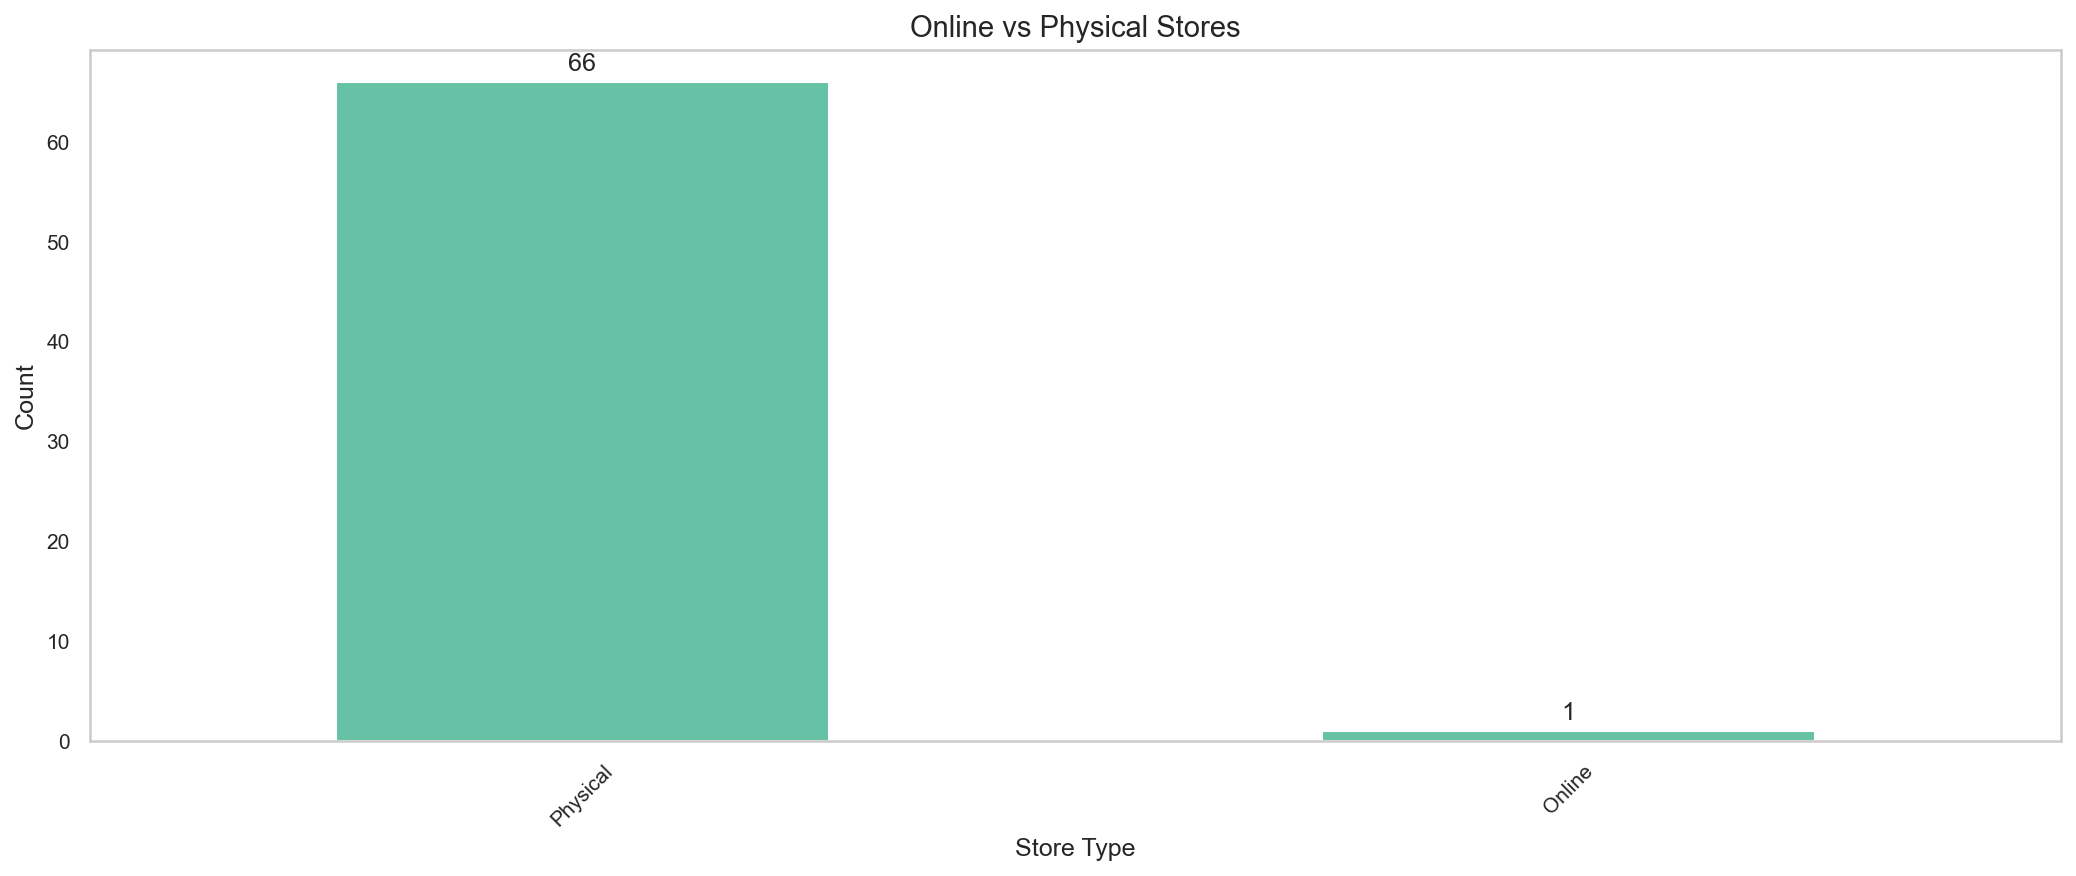

In [3]:
split = stores.online_vs_physical(df)
display(split)
fig, ax = split = base.bar(
    split,
    title="Online vs Physical Stores",
    xlabel="Store Type",
    ylabel="Count",
    filename="stores_online_vs_physical.png"
)

display(fig)

## Online Store Revenue (StoreKey 0 — reported separately)

In [4]:
online_rev = stores.online_store_revenue(df, sales)
display(f"Online store total revenue : ${online_rev:,.2f}")
display(f"Physical stores combined   : ${sales[sales['StoreKey'] != 0]['Revenue USD'].sum():,.2f}")

'Online store total revenue : $11,666,662.33'

'Physical stores combined   : $45,864,676.13'

## Store Count by Country

Country
United States     24
Germany            9
France             7
United Kingdom     7
Australia          6
Canada             5
Netherlands        5
Italy              3
dtype: int64

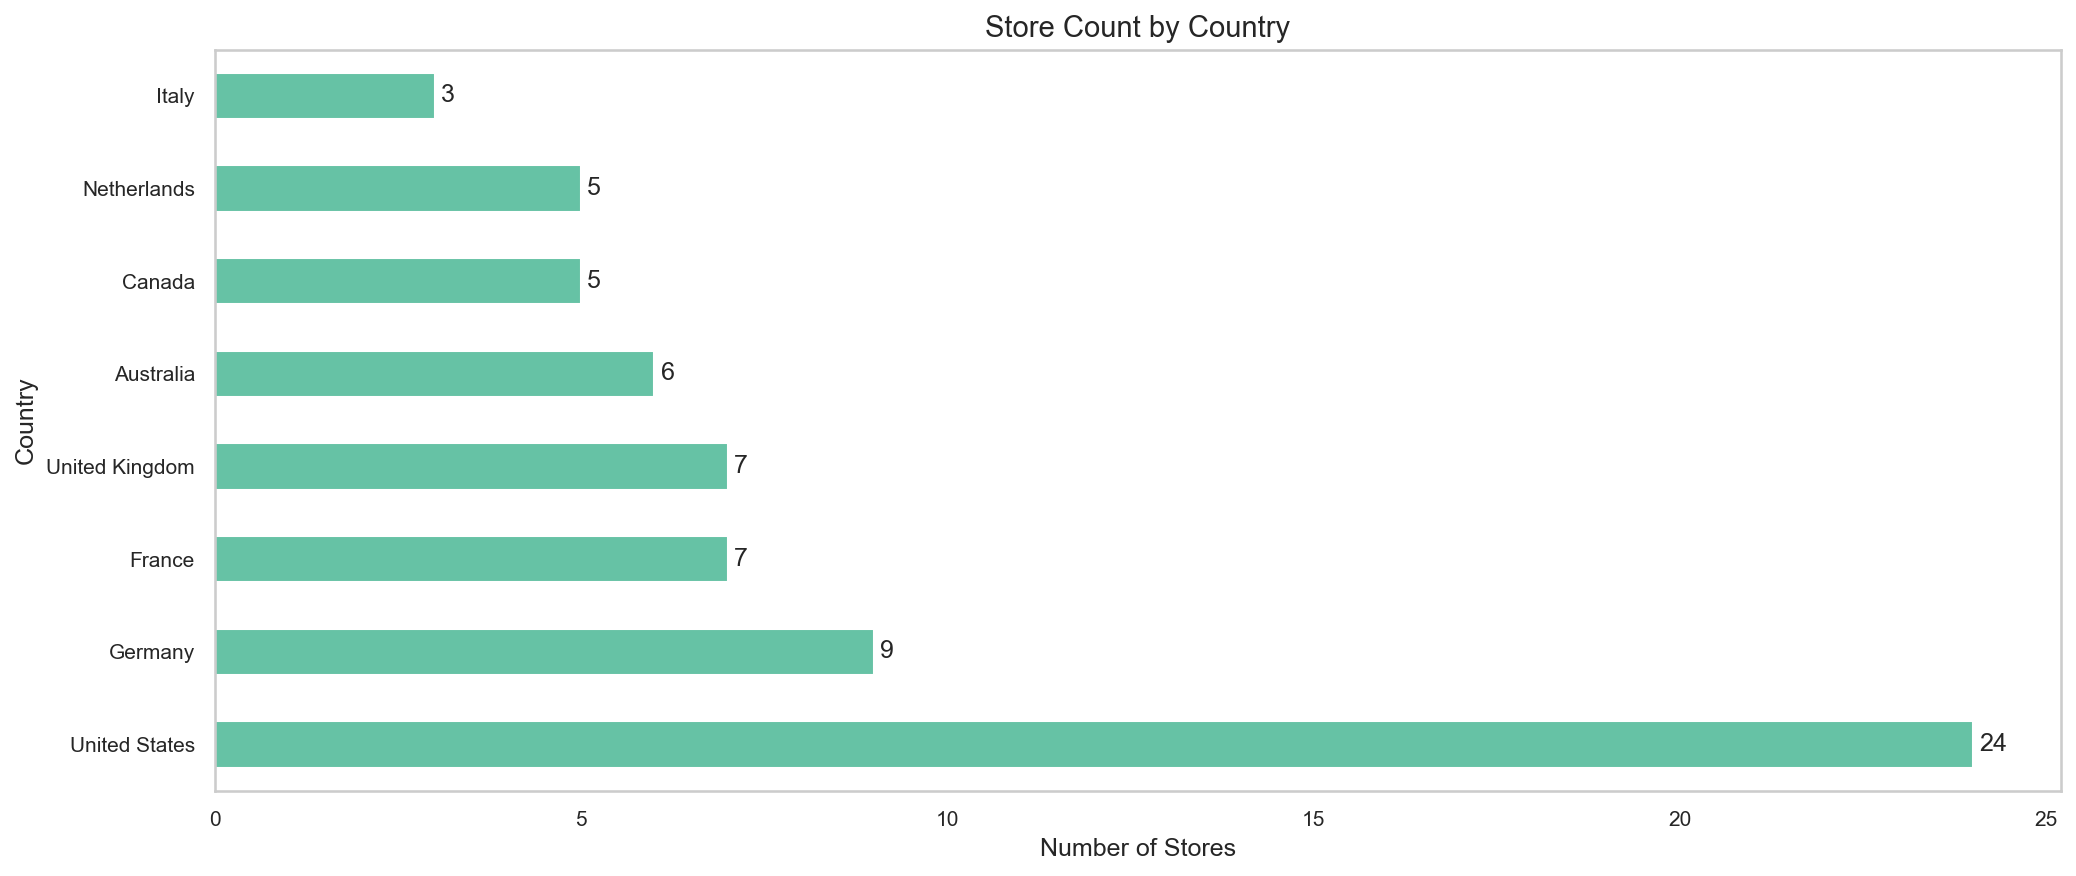

In [5]:
by_country = stores.stores_by_country(df)
display(by_country)
fig, ax = base.horizontal_bar(
    by_country,
    title="Store Count by Country",
    xlabel="Number of Stores",
    ylabel="Country",
    filename="stores_by_country.png"
)

display(fig)

## Store Size Distribution (Physical only)

count      66.00
mean     1402.20
std       576.40
min       245.00
25%      1108.75
50%      1347.50
75%      2000.00
max      2105.00
Name: Square Meters, dtype: float64

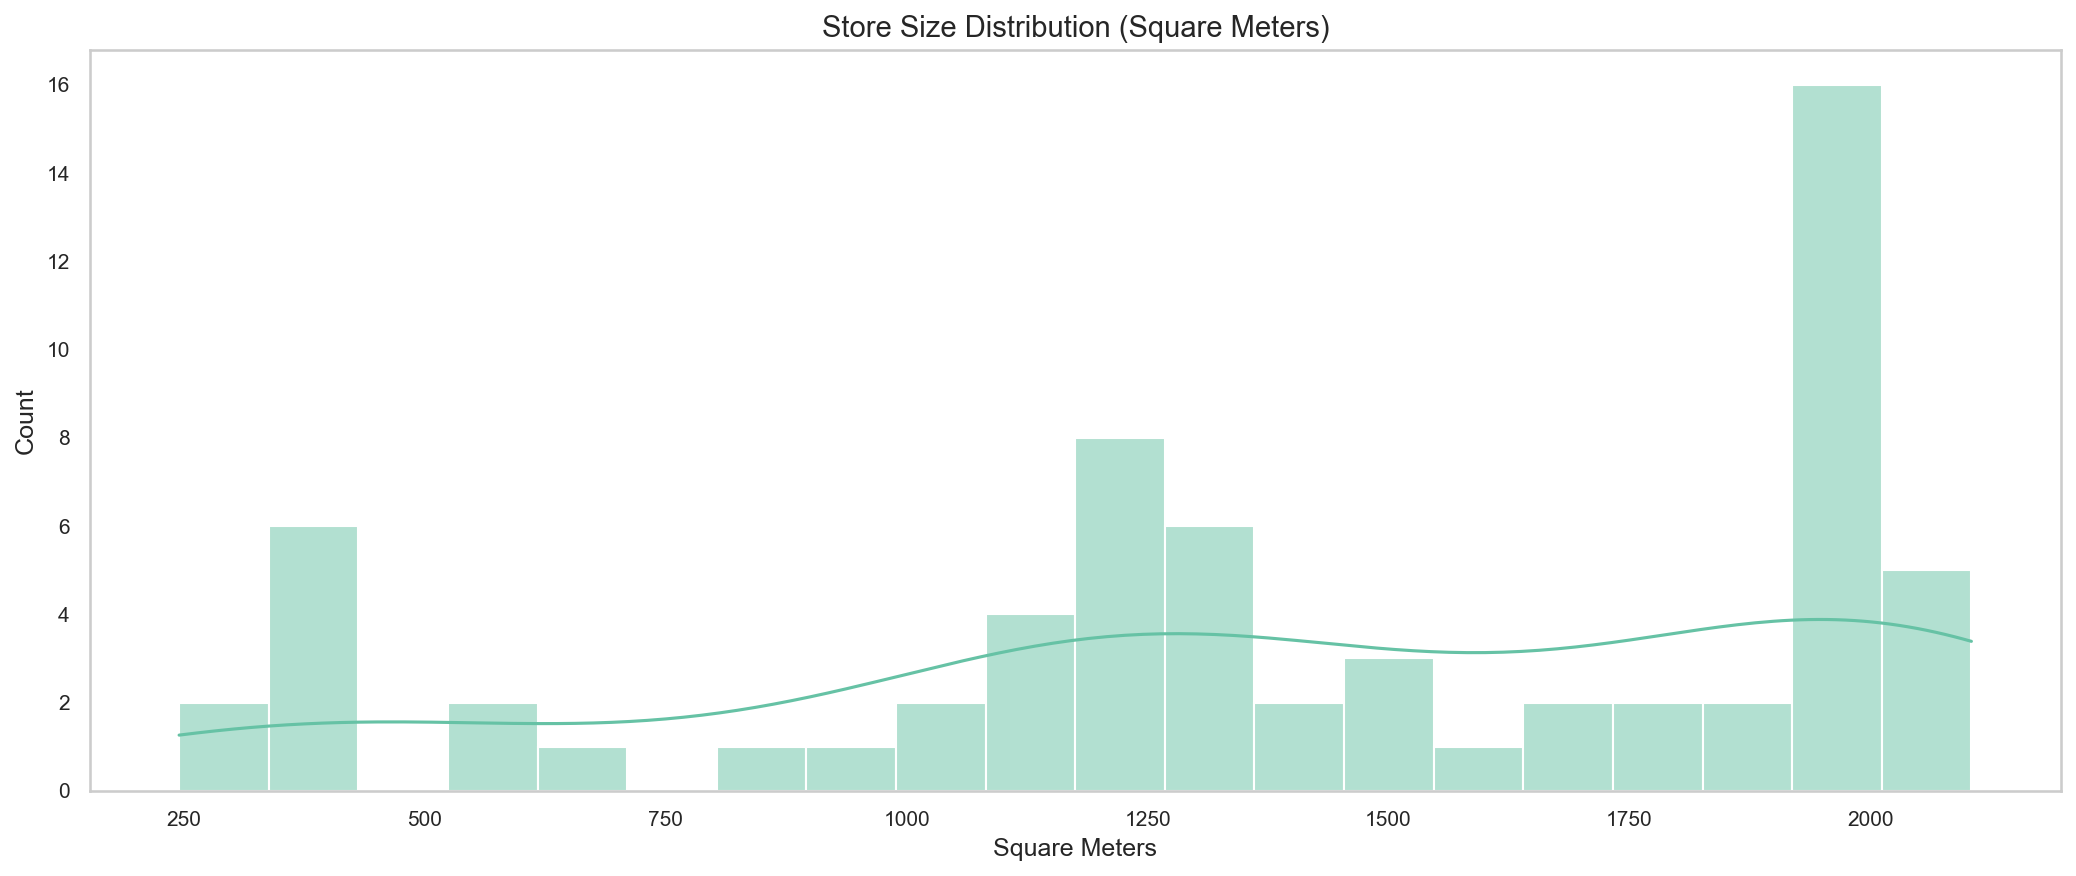

In [6]:
fig, ax = base.histogram(
    stores.store_size_distribution(df),
    title="Store Size Distribution (Square Meters)",
    xlabel="Square Meters",
    ylabel="Count",
    bins=20,
    filename="stores_size_distribution.png"
)
display(stores.store_size_stats(df))

display(fig)

## Average Store Size by Country

,Country,Square Meters
6,United Kingdom,1800.0
7,United States,1583.0
0,Australia,1543.0
4,Italy,1433.0
1,Canada,1426.0
3,Germany,1417.0
5,Netherlands,1225.0
2,France,341.0


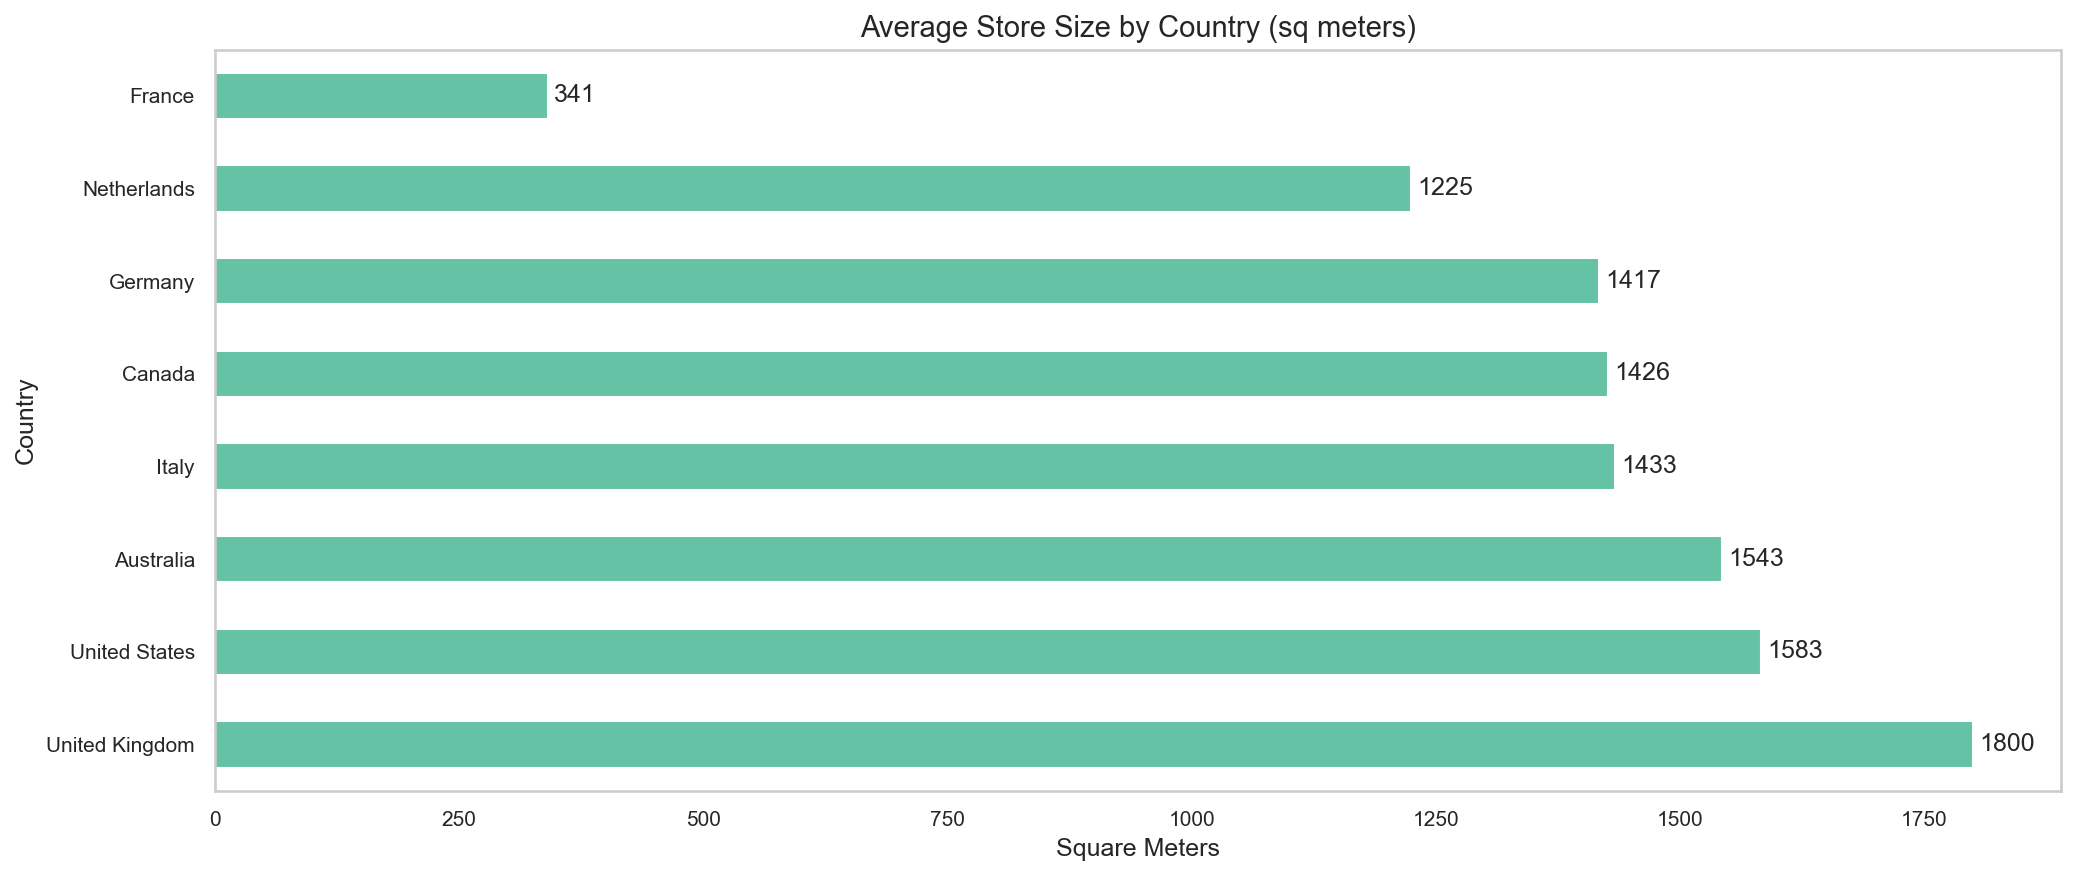

In [7]:
avg_size = stores.avg_store_size_by_country(df)
display(avg_size)
fig, ax = base.horizontal_bar(
    avg_size.set_index("Country")["Square Meters"],
    title="Average Store Size by Country (sq meters)",
    xlabel="Square Meters",
    ylabel="Country",
    filename="stores_avg_size_by_country.png"
)

display(fig)

## Store Age Distribution

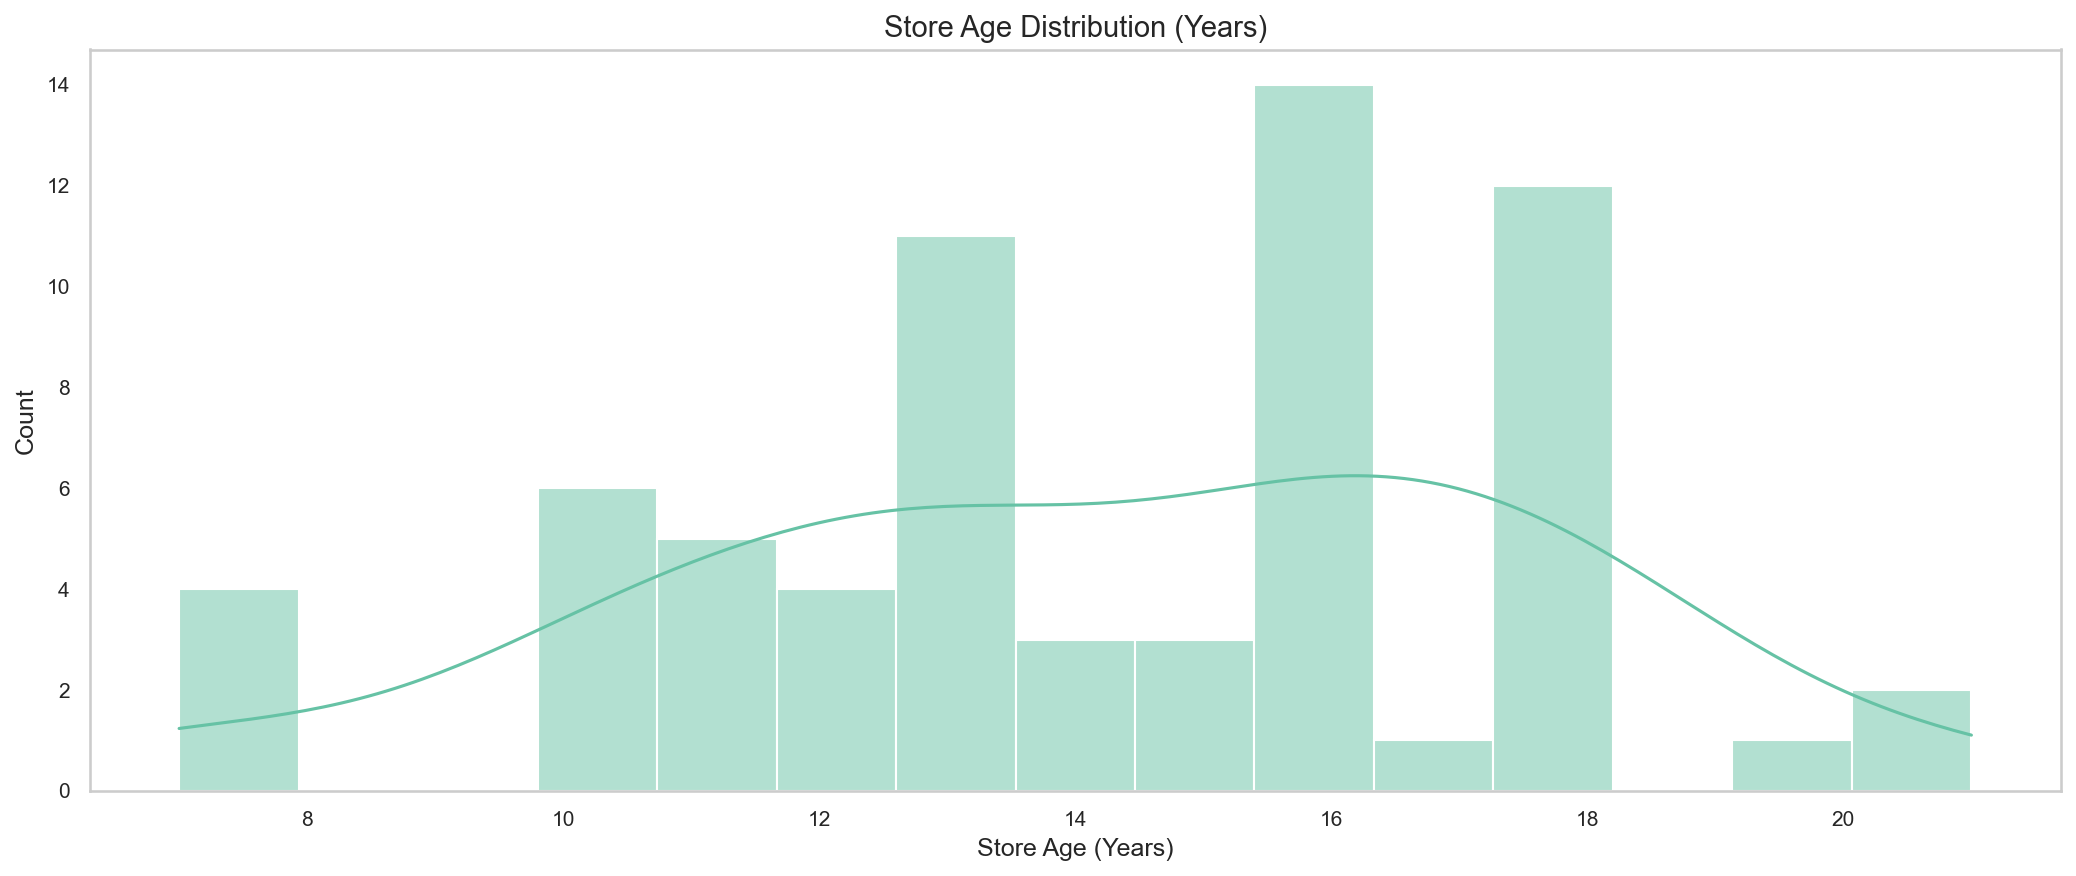

In [8]:
fig, ax = base.histogram(
    stores.store_age_distribution(df),
    title="Store Age Distribution (Years)",
    xlabel="Store Age (Years)",
    ylabel="Count",
    bins=15,
    filename="stores_age_distribution.png"
)

display(fig)

## Revenue per Store (Top 20)

,StoreKey,Country,Square Meters,Is Online Store,Revenue USD
54,55,United States,2000.0,False,1417885.41
49,50,United States,2000.0,False,1394738.06
53,54,United States,2000.0,False,1384396.24
56,57,United States,1645.0,False,1325611.89
44,45,United States,2000.0,False,1318787.92
60,61,United States,2000.0,False,1305684.43
58,59,United States,2000.0,False,1302272.44
37,38,United Kingdom,1800.0,False,1299956.87
63,64,United States,1330.0,False,1259350.98
42,43,United States,1190.0,False,1250255.14


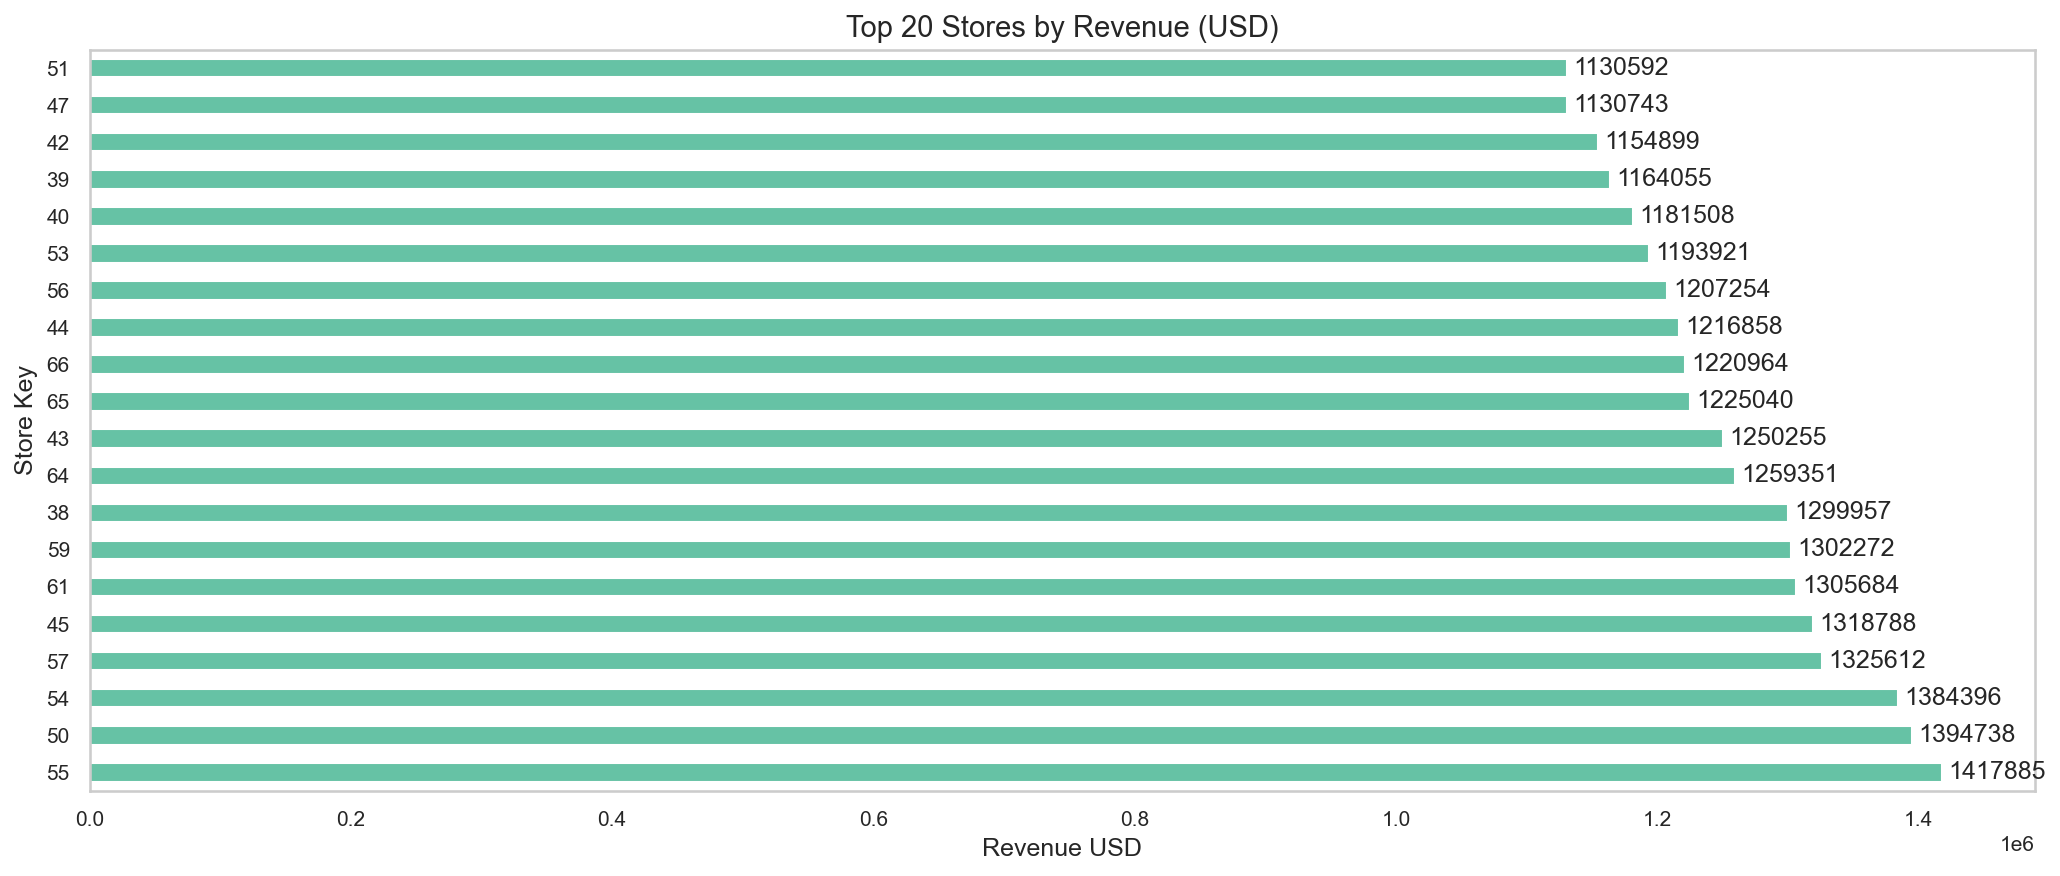

In [9]:
rev_per_store = stores.revenue_per_store(df, sales)
top20 = rev_per_store.head(20).set_index("StoreKey")["Revenue USD"]
display(rev_per_store[["StoreKey", "Country", "Square Meters", "Is Online Store", "Revenue USD"]].head(20))
fig, ax = base.horizontal_bar(
    top20,
    title="Top 20 Stores by Revenue (USD)",
    xlabel="Revenue USD",
    ylabel="Store Key",
    filename="stores_revenue_top20.png"
)

display(fig)

## Store Size vs Revenue (Physical stores only)

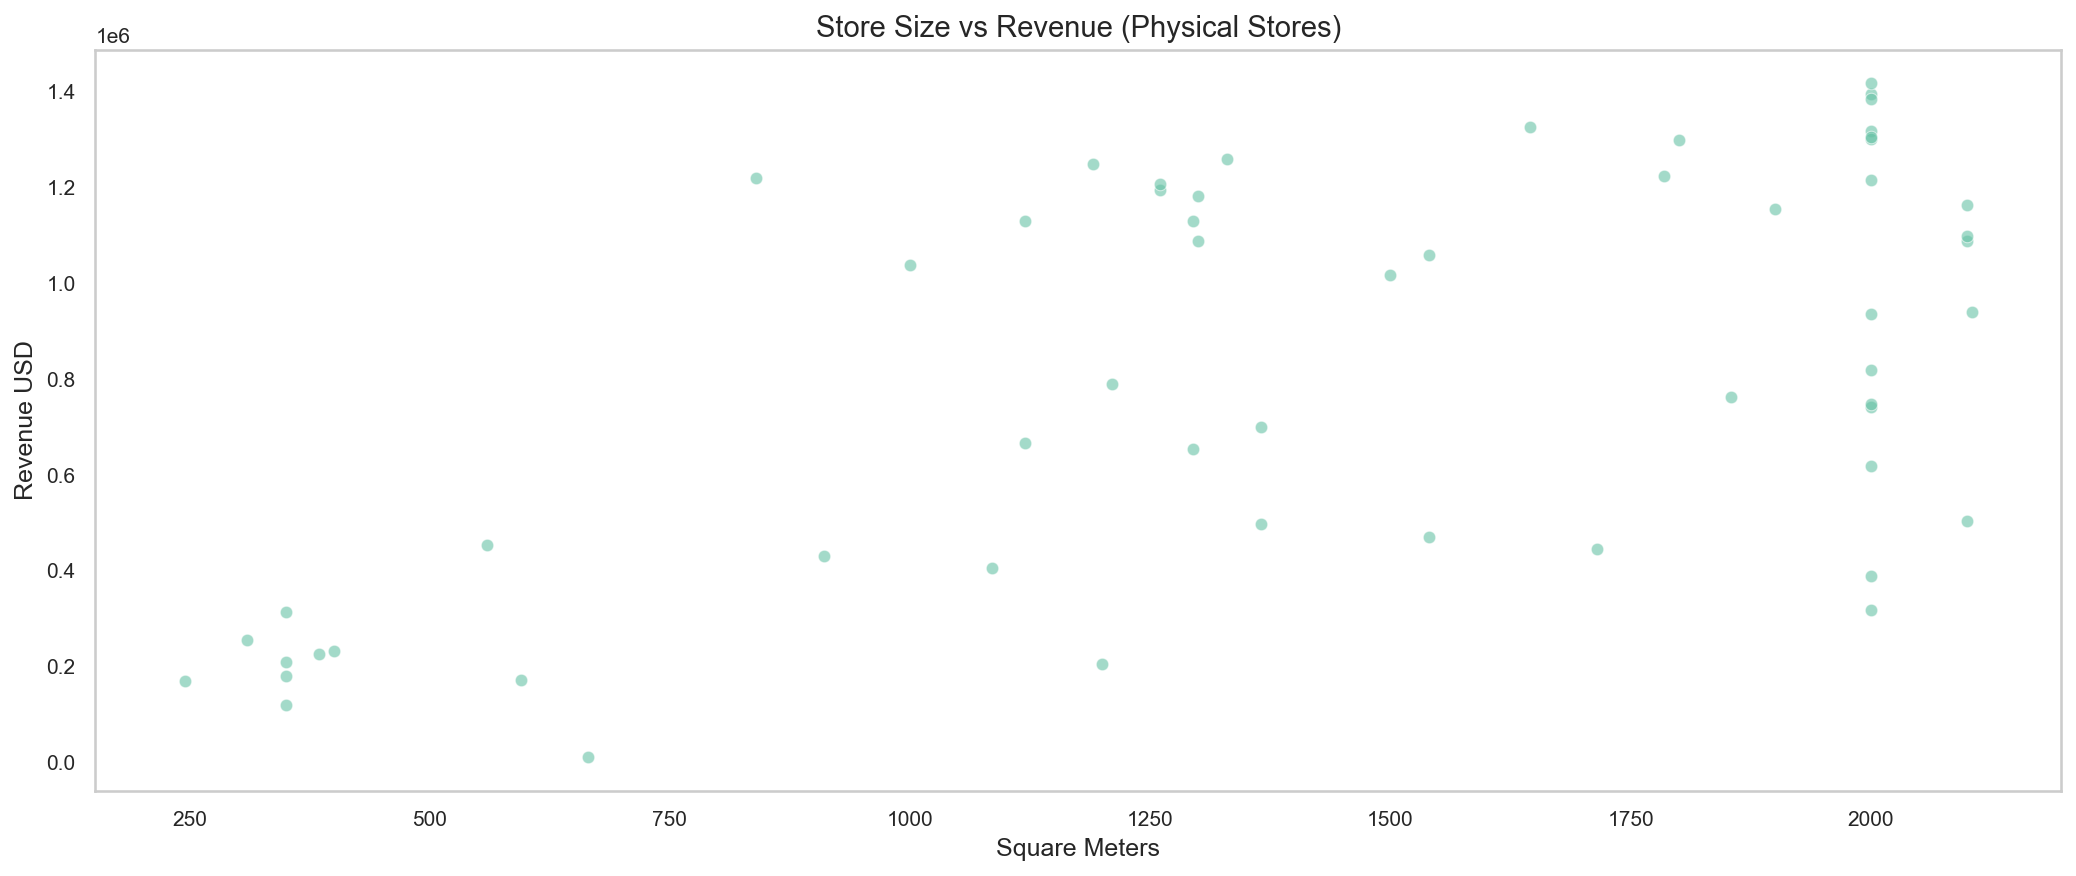

In [10]:
size_rev = stores.store_size_vs_revenue(df, sales)
fig, ax = base.scatter(
    size_rev,
    x="Square Meters",
    y="Revenue USD",
    title="Store Size vs Revenue (Physical Stores)",
    xlabel="Square Meters",
    ylabel="Revenue USD",
    filename="stores_size_vs_revenue.png"
)

display(fig)

## Store Analysis — Findings

### Store Network
- 67 total stores — 66 physical across 8 countries, 1 online (StoreKey 0).
- StoreKey 0 was identified as the online store because it is the only entry with a null
  Square Meters value — no physical size means no physical location.
- US dominates with 24 stores — more than all European countries combined (31 across 6 countries).
- Most stores are 13-18 years old — network was built between 2003 and 2008, no meaningful
  expansion since.

### Online vs Physical Revenue
| Channel | Revenue | Store Count | Avg Revenue per Store |
|---------|---------|-------------|----------------------|
| Physical | $45.9M | 66 | ~$695K |
| Online (StoreKey 0) | $11.7M | 1 | $11.7M |

- Online store is 17x more productive per storefront than the average physical store.

### Store Size
- Two distinct formats exist in the network — large (~2,000 sq m) and small (~300-400 sq m).
- US and UK lean toward large stores — UK average 1,800 sq m, US average 1,583 sq m.
- France is a clear outlier — 7 stores averaging just 341 sq m, less than a quarter of the UK average.
- Whether France's small format is a deliberate strategy or a market constraint is unknown from
  this data alone.

### Store Size vs Revenue
- Loose positive relationship — larger stores tend to earn more but the correlation is weak.
- At 2,000 sq m, revenue ranges from $300K to $1.4M — identical size, very different performance.
- Location and country market appear to matter more than floor space.
- One store around 650 sq m shows near-zero revenue across the full dataset period — flagged
  for investigation in deep dive.

### Top Physical Stores
- Top 20 stores cluster tightly between $1.1M and $1.4M — no single dominant outlier.
- Consistent performance across the top of the network — no store is carrying the others.